## Standardization Initiative Modelling Setup (SIMS)

This notebook serves as a high level walk-through of the idea behind the standardization initiative modelling setup (SIMS), it serves as an intial introduction to the basis principles and a way to interact with the availble code to enable users to develop their own modelling systems. 

However, prior to being able to develop medical image analysis deep learning models, data collection is required, a very broad outline of any model development in medical image anlysis looks something like:

0) Gather raw data, image + end-point data is gathered throughout the clincal workflow
1) Process data, gather data from clinical repositories and convert to standardized ("clean") model input
2) Use data to train, evaluate and experiment with different models <- this is SIMS!!
3) Validate and employ models 

SIMS works with a set expected structure of data (output step 1):

Data\
└── dataset
>   ├── Tabular information\
    │   ├── Data1.csv\
    │   ├── Data2.csv\
    │   └── ...
>>    └── Image information \
        ├── PatientID_0001\
        │   ├── VOL1.npy\
        │   ├── VOL2.npy\
        │   └── VOL3.npy\
        ├── PatientID_0002\
        │   ├── VOL1.npy\
        │   ├── VOL2.npy\
        │   └── VOL3.npy\
        └── ...

In this notebook we will use the public dataset for Lung radiomics dataset (CT, segmentations, survival): NSCLC-RADIOMICS - The Cancer Imaging Archive (TCIA): [https://www.cancerimagingarchive.net/collection/nsclc-radiomics/](https://www.cancerimagingarchive.net/collection/nsclc-radiomics/)

A way to pre-process to get the SIMS this data is provided in: NOTEBOOKNAME. 

Tabular information is stored in csv files containing patient's clinical data, and information needed for the deep learning models you can develop usings SIMS. 

The csv files should contain (at least) PatientID as key identifier (should be the same as the folder name of the patient), the to be predicted end-point (in this example survival of lung patients) and the set the patients belong to (either testing set "test" or the training/validation set "train_val"). 

Image (volume) information is stored in the .npy format. These files should contain (preferably registered) volumetric information. The .npy files can be either contain pre-normalized or can be normalized during the modelling process.

In [1]:
# Local libraries enivironment loading
import os
import numpy as np
import sys
from pathlib import Path
path_Project = Path(os.getcwd()).parent.parent
path_Git = path_Project.parent
def IncludeDirectory(path, index = 0, indexStop = -1):
    if(os.path.exists(path) and (index <= indexStop or indexStop == -1)):
        sys.path.append(path)
        children = os.listdir(path)
        for i in range(len(children)):
            pathChild = os.path.join(path,children[i])
            if(os.path.isdir(pathChild)):
                IncludeDirectory(pathChild, index + 1, indexStop)

# Activate the function
IncludeDirectory(path_Git,0,1)
from src.visualization.plot_slices import plot_slices
from src.config_presets.tools.get_config import get_config
from src.utils.set_random_seed import set_random_seed
from src.experiments.experimentHandler import experimentHandler
from src.utils.logging.logging import setup_logging

C:\Users\HoekL02\AppData\Local\anaconda3\envs\SIMS\Lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


### Load and visualize example dataset

In [2]:
import pandas as pd

# Lets load our example dataset
df = pd.read_csv(r'\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Public_datasets\TCIA_Lung_tabular/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv')

In [3]:
# Check some of the tabular data
df.head()

,PatientID,age,clinical.T.Stage,Clinical.N.Stage,Clinical.M.Stage,Overall.Stage,Histology,gender,Survival.time,deadstatus.event
0,LUNG1-001,78.7515,2.0,3,0,IIIb,large cell,male,2165,1
1,LUNG1-002,83.8001,2.0,0,0,I,squamous cell carcinoma,male,155,1
2,LUNG1-003,68.1807,2.0,3,0,IIIb,large cell,male,256,1
3,LUNG1-004,70.8802,2.0,1,0,II,squamous cell carcinoma,male,141,1
4,LUNG1-005,80.4819,4.0,2,0,IIIb,squamous cell carcinoma,male,353,1


In [4]:
# A singular patients
print("Patient:",df["PatientID"][0],"\nEndpoint(time, status):",df["Survival.time"][0],',',df["deadstatus.event"][0])

Patient: LUNG1-001 
Endpoint(time, status): 2165 , 1


C:\Users\HoekL02\AppData\Local\Temp\ipykernel_42356\4016185989.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


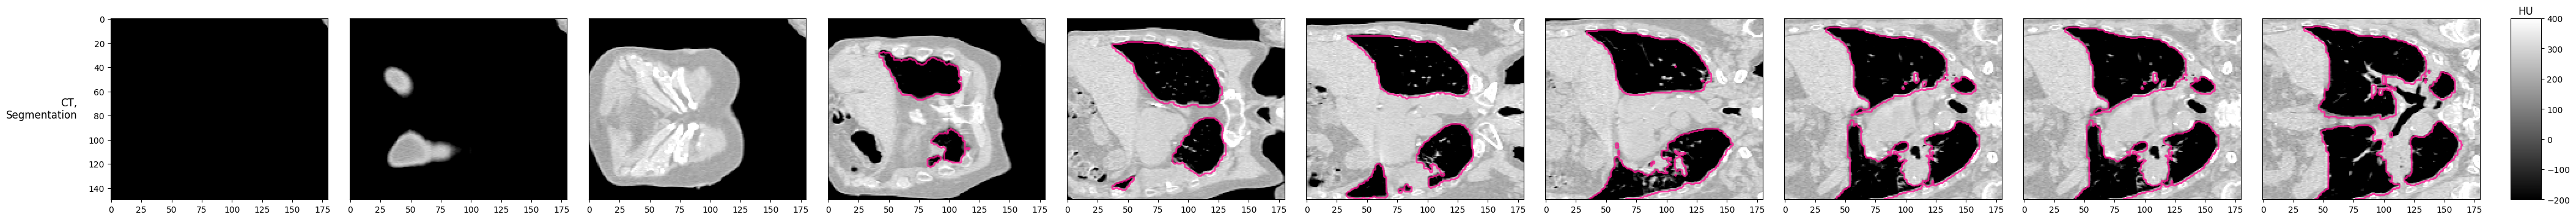

In [5]:
# Load our example patient's imaging data
ct = np.load(r'\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Public_datasets\TCIA_lung_processed2\LUNG1-001/CT_resampled_cropped.npy')
seg = np.load(r'\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Public_datasets\TCIA_lung_processed2\LUNG1-001/LungMask_resampled_cropped.npy')

patient_base_plots = [
{
    "Label": "CT,\nSegmentation",
    "CT": ct*1000-600,
    "RTSTRUCT": seg
},
]

slice_index = [10, 20, 30, 40, 50, 60, 70, 80, 80, 90]

fig, axs = plot_slices( patient_base_plots,slice_index,title = '') 

fig.show()

In [6]:
# To use this data in our model we need to add information about the set each of patients belong to
# Lets make the first 20% patients test and all others training/val
test = ['test']*(int(0.2*len(df)))
train_val = ['train_val']*(len(df)-(int(0.2*len(df))))
df['Split'] = test + train_val

# Save the patient info
df['survival_event'] = df['deadstatus.event']
df['survival_days'] = df['deadstatus.event']
df.to_csv(r'\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Public_datasets\TCIA_Lung_tabular/TCIA.csv')

## On the use of config files for SIMS

Shown above are example inputs and outputs which we will use to train a model. However now that we have data we still need an actual model, a way to feed the data to the model and a way to then optimize the model. Luckily all these steps are integrated into the SIMS workflow, however decision are to be made. As a way of standardizing the decision making process config files are used (these basically act as dictionary containing any required info).

SIMS works with a base config and a customizable config, in general it is recomended for users to produce a single config per project. The base config serves a a method to standerdize and 'hide' some of the options that are provided, for instance seeds used during randomization (training and data augmentation) or even a standardized model configuration. It is highly recommended to check the base config: ....PATH TO BASE CONFIG... , here we will walk through some of the key features and generate our own config for this example project, make a copy of the base config and adjust the required paths.

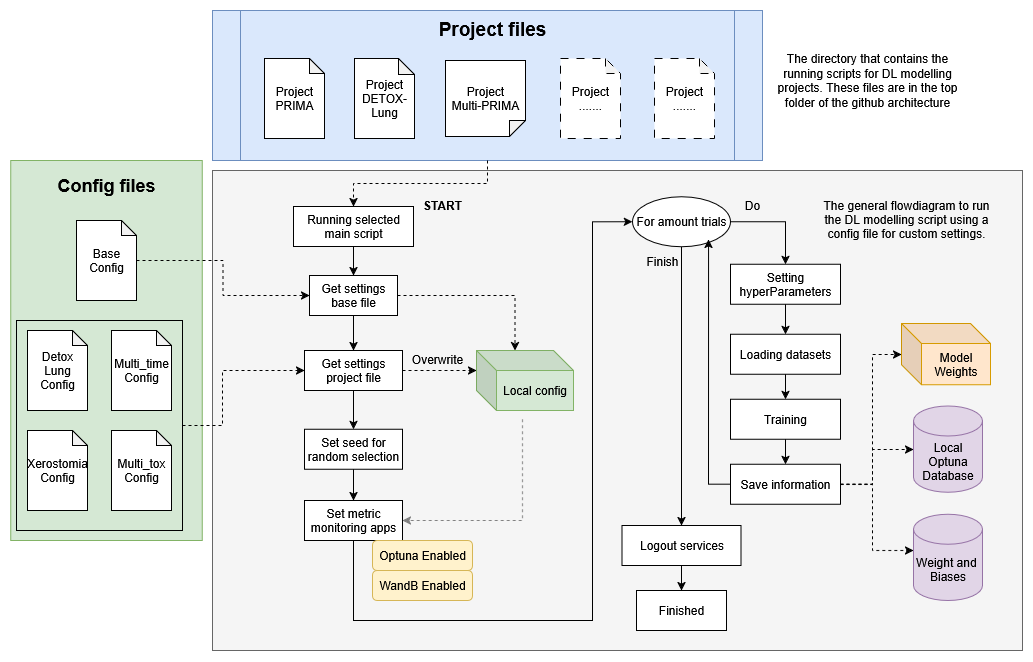

In [7]:
base_config_copy = get_config('Base_config',pathGiven= r'C:\Users\HoekL02\OneDrive - UMCG\Documents\GitHub\pred_RT_SIMS/')
print(base_config_copy)

{'general': {'region': 'HNC', 'seed': 42, 'firstRun': False, 'experiment_name': 'Base_Experiment', 'trialNumber': 'Trial_0', 'resultsCurrentDirectory': '', 'testMode': False, 'use_test_set': False, 'dataset_amounts_experiment': False}, 'columns': {'labels': ['Xerostomia_M06', 'OS'], 'labels_types': ['Binary', 'Event'], 'clinical_features': ['Xerostomia_W01_Helemaal_niet', 'Xerostomia_W01_Een_beetje', 'Xerostomia_W01_Nogal_Heel_erg', 'Sex', 'Age']}, 'paths': {'csv': '//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Luuk vd Hoek/Projects collection/Mini projects/SIMS/bagged_datasets/xerostomia_m06/', 'images': '//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Luuk vd Hoek/Projects collection/Mini projects/SIMS/dataset/patients/', 'results': '//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Luuk vd Hoek/Projects collection/Mini projects/SIMS/hnc-ensemble-master/results/'}, 'model': {'model_name': 'resnet', 'output_head': {'name': 'multilabel', 'n_linear_layers': 1, 'linear_

In [8]:
# Here we set the relevant labels (and types) and the input from the clinical features
base_config_copy['columns']['labels'] = ['survival']
base_config_copy['columns']['labels_types'] = ['Event']
base_config_copy['data']['event_endpoint_time_unit'] = 'days'
base_config_copy['columns']['clinical_features'] = []

# One thing that should always be checked is where the data is stored and you want 
# the results of your models to be saved 
base_config_copy['paths']['csv'] = r'\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Public_datasets\TCIA_Lung_tabular/'
base_config_copy['data']['dataset_csv'] = 'TCIA.csv'
base_config_copy['paths']['images'] = r'\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Public_datasets\TCIA_lung_processed2/'
base_config_copy['paths']['results'] = r'C:\Users\HoekL02\OneDrive - UMCG\Desktop/results_sims_test/'

# 

# Modular modelling using SIMS

SIMS follows a modular system for any of the models developed using it, consisting of four parts:
> 1) Image(s), 3D volumes containing information used as input for the model
> 2) Convolutional backbone, used a generalized feature exraction from the image(s)
> 3) Fully conected linear layers, here all input features are combined into a final prediction for the end point(s)
> 4) Clinical features processinging, this consists of an MLP which are concatonated to the linear layers to combined tabular and image information

See the image below:

[image.png](attachment:450a8bb1-afdc-43d4-9563-7cb303347e79.png)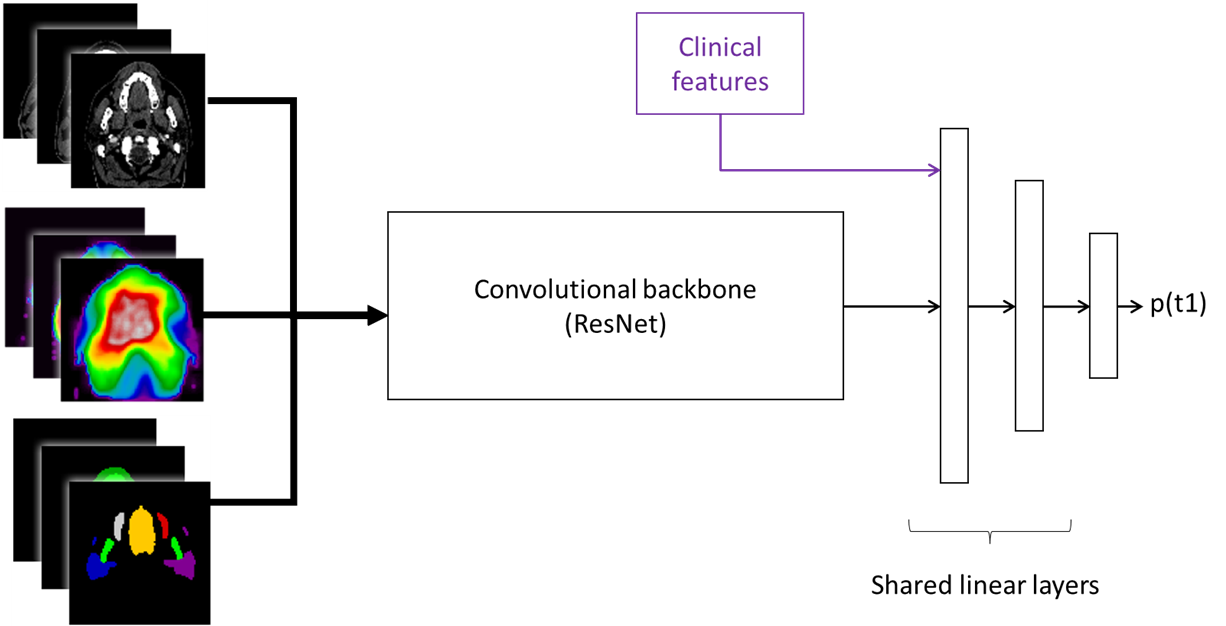

All these subsections are highly customizable using the config, based on the available models. 


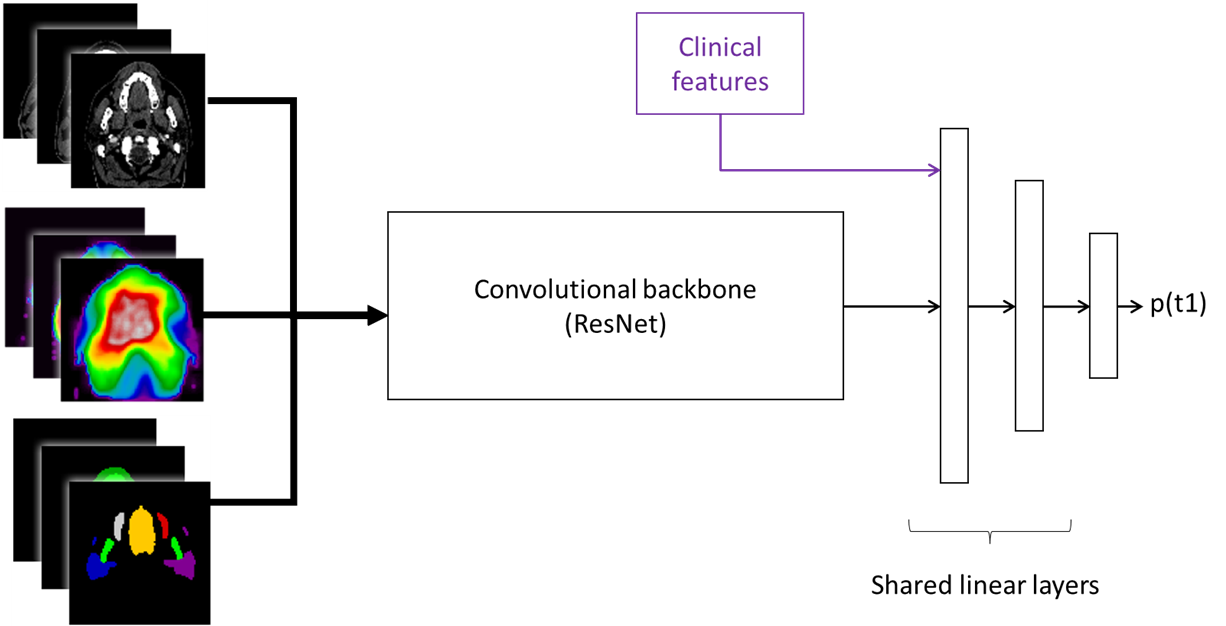

In [9]:
# 1) Images
base_config_copy['data']['image_keys'] = ['CT_resampled_cropped','LungMask_resampled_cropped']
# 2) Convolutional backbone
base_config_copy['model']['model_name'] = 'resnet' # options: ['cnn', 'resnet', 'densenet', 'ViT', 'TransRP']
# 3) Fully connected layer
# For now we will keep these at the default setting
# 4) Clinical feature processing
# For now we will keep these at the default setting

## Integration with weights and biases

SIMS has weights and biases (WandB) intregrated into its design, WandB can be used to monitor your models during training and assess optimal configurations during hyperparameter tuning.

Do be carefull though! The API key will be saved in the config file and any subsequently produced config files from the experiment, so if you use a shared data space other users will be able to find your weights and biases API key!

Below you can enable WandB and provide it with your API key, which will be used to send results to your own WandB enviroment. 

In [10]:
base_config_copy['hyperparam_tuning']['WandB']['isEnabled'] = False
base_config_copy['hyperparam_tuning']['WandB']['API_Key'] = "INSERT YOUR API KEY"

## Training a model

In [ ]:
base_config_copy['hyperparam_tuning']['optuna']['isEnabled'] = False

setup_logging('INFO')

# Load the config
config = base_config_copy # alternatively you can save and load your config

# Disable randomness
set_random_seed(config['general']['seed'])
config['saving']['plot_training_slices']['isEnabled'] = False

# # MAIN: DL running class (with optional hyperparameter optimization)
expHandler = experimentHandler(config)
expHandler.run_experiment(config)

[09:12:50] INFO     Starting up experiment handler...                                       experimentHandler.py:19

           INFO     Removed patients (no image data) = 17                                        load_dataset.py:59

           INFO     Train/Val dataset 325 (80.24691358024691%), Test dataset 80                 load_dataset.py:102
                    (19.753086419753085%)                                                                          

           INFO     Directory path updated: C:\Users\HoekL02\OneDrive -              create_results_directory.py:47
                    UMCG\Desktop/results_sims_test/Base_Experiment\Trial_0\KFold1                                  

           INFO     Fold 1/5                                                          k_fold_cross_validation.py:90

C:\Users\HoekL02\AppData\Local\anaconda3\envs\SIMS\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\HoekL02\AppData\Local\anaconda3\envs\SIMS\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


## Evaluation and visualization

Technically the outcome of the main files determines how the evaluation of the procedure is done:
- If just a config file is saved we have to use the config file in a generic train (main) function to initialize the model prior to evaluation
- If the model weights and config are saved we can just intitiate a model using the config to determine the architeture and loading the weights
- If the predictions are also saved we can do all result based evaluation/ visualization directly on the predictions
    




In [ ]:
# # # # run the models on the test set
trial_dir = config['general']['resultsCurrentDirectory']
validate_models_on_test_set(config, trial_dir)